# Análisis de Mañaneras — Conteo por Grupo
### Versión fácil de editar: un grupo a la vez

Este notebook analiza **un solo grupo** (por ejemplo "Ambientalistas", "Empresarios", "Periodistas"), combinando:
- **Personajes** específicos del grupo (personas con nombre propio) → conteo **exacto** de menciones.
- **Palabras clave** del grupo (temas, sin nombres propios) → conteo **sumado**.

> **Solo se necesita editar la sección de CONFIGURACIÓN** — incluyendo el nombre del grupo, los personajes, las palabras clave y los títulos de las gráficas.

---
## CONFIGURACIÓN

In [1]:
# =============================================================
# CONFIGURACIÓN
# =============================================================

# Carpeta local donde están guardados tus archivos .docx
RUTA_DATOS = "./data/mananeras"

# Rango de fechas del análisis
FECHA_INICIO = "2018-12-01"   # formato: AAAA-MM-DD
FECHA_FIN    = "2026-01-31"   # formato: AAAA-MM-DD

# Corte entre presidencias
FECHA_CAMBIO_PRESIDENTE = "2024-10-01"

# NOMBRE DEL GRUPO 
NOMBRE_GRUPO = "Ambientalistas"

# =============================================================
# PERSONAJES DEL GRUPO
# Nombres propios de personas específicas. Cada quien puede tener
# varias variantes (nombre completo, apellido, apodo) — todas se suman.
# =============================================================
PERSONAJES_CONTEO = {
    "Marco Antonio Suástegui": ["Marco Antonio Suástegui", "Suástegui"],
    "Marcelo Pérez Pérez":     ["Marcelo Pérez Pérez", "Marcelo Pérez"],
    "Abel Barrera":            ["Abel Barrera"],

    # "Nombre del personaje": [
    #     "nombre completo", "apellido", "variante o apodo",
    # ],
}

# =============================================================
# PALABRAS CLAVE DEL GRUPO
# Una sola lista de términos — todos se suman en un solo conteo.
# =============================================================
PALABRAS_CLAVE = [
    "ambientalista", "ambientalistas", "ecologista", "ecologistas",
    "medio ambiente", "cambio climático", "activismo ambiental"

    # "otro término",
    # "otra frase clave",
]

# =============================================================
# TÍTULOS DE LAS GRÁFICAS (editable)
# =============================================================
TITULO_GRAFICA_PERSONAJES     = f"{NOMBRE_GRUPO} — Menciones directas de personajes"
TITULO_GRAFICA_PALABRAS_CLAVE = f"{NOMBRE_GRUPO} — Menciones de palabras clave (evolución mensual)"

print("✅ Config guardada.")
print(f"   Grupo: {NOMBRE_GRUPO}")
print(f"   Personajes: {list(PERSONAJES_CONTEO.keys())}")
print(f"   Palabras clave: {PALABRAS_CLAVE}")


✅ Config guardada.
   Grupo: Ambientalistas
   Personajes: ['Marco Antonio Suástegui', 'Marcelo Pérez Pérez', 'Abel Barrera']
   Palabras clave: ['ambientalista', 'ambientalistas', 'ecologista', 'ecologistas', 'medio ambiente', 'cambio climático', 'activismo ambiental']


---
## CÓDIGO BASE — No modificar

### Carga de archivos locales (.docx)

In [2]:
import os, re
from datetime import datetime
from docx import Document
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Parsear fechas de configuración
_fecha_inicio = datetime.strptime(FECHA_INICIO, "%Y-%m-%d")
_fecha_fin    = datetime.strptime(FECHA_FIN,    "%Y-%m-%d")
_fecha_cambio = datetime.strptime(FECHA_CAMBIO_PRESIDENTE, "%Y-%m-%d")

# diccionario aux meses
_MESES_ES = {
    "ENE": 1, "FEB": 2, "MAR": 3, "ABR": 4,
    "MAY": 5, "JUN": 6, "JUL": 7, "AGO": 8,
    "SEP": 9, "OCT": 10, "NOV": 11, "DIC": 12
}

def _extraer_fecha(nombre):
    m = re.search(r'([A-Za-z]{3})[-_](\d{4})', nombre)
    if m:
        mes_str = m.group(1).upper()
        año = int(m.group(2))
        mes = _MESES_ES.get(mes_str)
        if mes:
            return datetime(año, mes, 1)
    return None

def _cargar_corpus():
    if not os.path.exists(RUTA_DATOS):
        print(f"⚠️  Carpeta no encontrada: {RUTA_DATOS}")
        print("   Verifica que RUTA_DATOS apunte a la carpeta correcta en tu computadora.")
        return []
    archivos = []
    sin_fecha = []
    for nombre in sorted(os.listdir(RUTA_DATOS)):
        if not nombre.lower().endswith('.docx'):
            continue
        fecha = _extraer_fecha(nombre)
        if not fecha:
            sin_fecha.append(nombre)
            continue
        if not (_fecha_inicio <= fecha <= _fecha_fin):
            continue
        ruta = os.path.join(RUTA_DATOS, nombre)
        try:
            doc = Document(ruta)
            texto = ' '.join(p.text.strip() for p in doc.paragraphs if p.text.strip())
            presidente = "AMLO" if (fecha.year, fecha.month) < (_fecha_cambio.year, _fecha_cambio.month) else "Claudia Sheinbaum"
            archivos.append({
                'fecha':      fecha,
                'mes':        fecha.strftime('%Y-%m'),
                'año':        fecha.year,
                'presidente': presidente,
                'texto':      texto,
                'n_palabras': len(texto.split())
            })
        except Exception as e:
            print(f"   ⚠️  Error leyendo {nombre}: {e}")

    print(f"✅ {len(archivos)} archivos cargados")
    print(f"   Período: {_fecha_inicio.strftime('%b %Y')} → {_fecha_fin.strftime('%b %Y')}")
    dist = pd.Series([d['presidente'] for d in archivos]).value_counts()
    for p, n in dist.items():
        print(f"   {p}: {n} archivos")
    if sin_fecha:
        print(f"\n   ⚠️  {len(sin_fecha)} archivos ignorados (no se pudo leer fecha del nombre):")
        for f in sin_fecha[:5]:
            print(f"      {f}")
    return sorted(archivos, key=lambda x: x['fecha'])

_corpus = _cargar_corpus()


✅ 86 archivos cargados
   Período: Dec 2018 → Jan 2026
   AMLO: 70 archivos
   Claudia Sheinbaum: 16 archivos


---
## Personajes — menciones exactas por fecha

Conteo literal (no tasa) de cada personaje. Una sola gráfica con **una línea por personaje**,
mostrando la fecha exacta de cada mañanera en la que hubo al menos una mención.

════════════════════════════════════════════════════════════
  AMBIENTALISTAS — MENCIONES TOTALES POR PERSONAJE
════════════════════════════════════════════════════════════
persona
Marco Antonio Suástegui    14
Marcelo Pérez Pérez         5
Abel Barrera                1
════════════════════════════════════════════════════════════


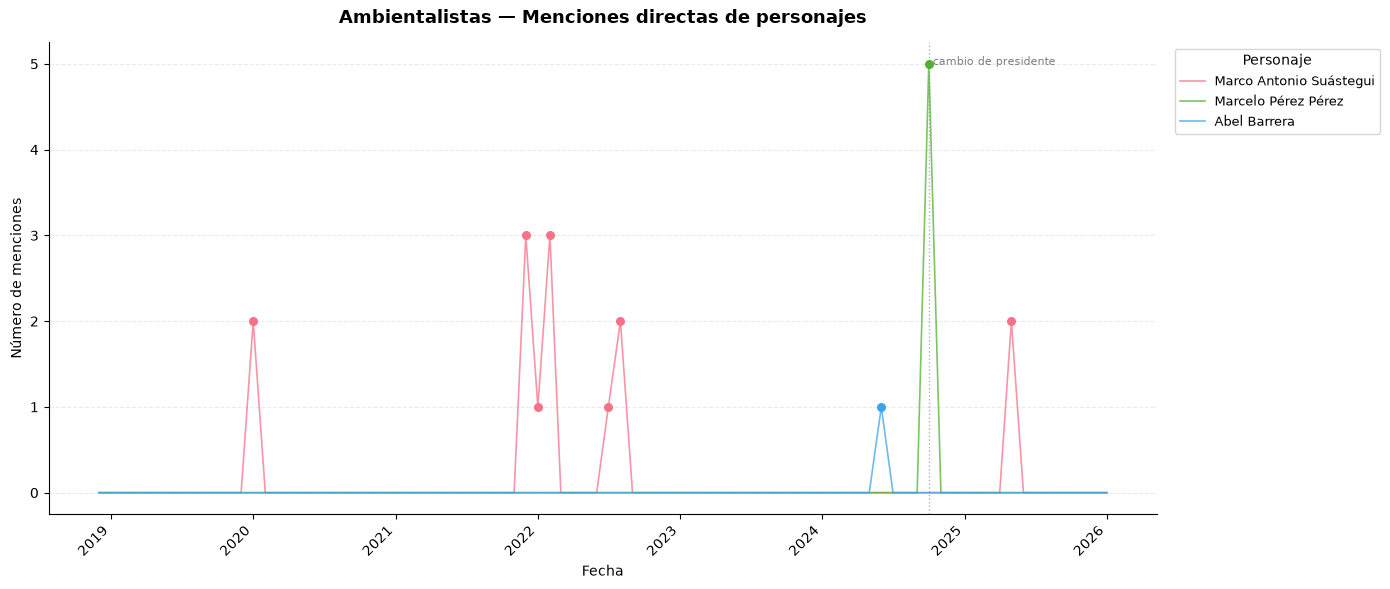


Gráfica guardada: ambientalistas_personajes_timeline.png


In [4]:
# ============================================================
#  PERSONAJES — CONTEO EXACTO (número de menciones, no tasa)
# ============================================================

def _contar(texto, terminos):
    texto_l = texto.lower()
    return sum(
        len(re.findall(r'\b' + re.escape(t.lower()) + r'\b', texto_l))
        for t in terminos
    )

if not _corpus:
    print("No hay archivos cargados. Revisa RUTA_DATOS y vuelve a ejecutar la celda de carga.")
else:
    filas_p = []
    for doc in _corpus:
        for persona, variantes in PERSONAJES_CONTEO.items():
            menciones = _contar(doc['texto'], variantes)
            filas_p.append({
                'fecha':      doc['fecha'],
                'presidente': doc['presidente'],
                'persona':    persona,
                'menciones':  menciones
            })
    df_personajes = pd.DataFrame(filas_p)

    # ── Tabla resumen ──────────────────────────────────────────
    print("═"*60)
    print(f"  {NOMBRE_GRUPO.upper()} — MENCIONES TOTALES POR PERSONAJE")
    print("═"*60)
    resumen_p = df_personajes.groupby('persona')['menciones'].sum().sort_values(ascending=False)
    print(resumen_p.to_string())
    print("═"*60)

    # ── Gráfica: una línea por personaje, incluyendo los días sin
    #    mención (valor 0) para no dar la impresión de que el nivel
    #    se mantiene constante entre una mención y la siguiente ──
    _paleta_p = sns.color_palette("husl", len(PERSONAJES_CONTEO))

    fig, ax = plt.subplots(figsize=(14, 6))
    for persona, color in zip(PERSONAJES_CONTEO.keys(), _paleta_p):
        dp = df_personajes[df_personajes['persona'] == persona].sort_values('fecha')
        if dp.empty:
            continue
        # línea completa (pasa por 0 en los días sin mención)
        ax.plot(dp['fecha'], dp['menciones'], linewidth=1.2, alpha=0.75,
                 color=color, label=persona, zorder=2)
        # marcadores solo en fechas con mención real (>= 1)
        dp_marcas = dp[dp['menciones'] >= 1]
        if not dp_marcas.empty:
            ax.scatter(dp_marcas['fecha'], dp_marcas['menciones'],
                       color=color, s=30, zorder=3)

    # Línea de referencia: cambio de presidente
    ax.axvline(_fecha_cambio, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    if ax.get_ylim()[1] > 0:
        ax.text(_fecha_cambio, ax.get_ylim()[1]*0.97, ' cambio de presidente',
                fontsize=8, color='gray', va='top')

    ax.set_title(TITULO_GRAFICA_PERSONAJES, fontsize=13, fontweight='bold', pad=14)
    ax.set_xlabel("Fecha", fontsize=10)
    ax.set_ylabel("Número de menciones", fontsize=10)
    ax.legend(title="Personaje", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.spines[['top','right']].set_visible(False)
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()

    _nombre_archivo = NOMBRE_GRUPO.lower().replace(' ', '_')
    plt.savefig(f"{_nombre_archivo}_personajes_timeline.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nGráfica guardada: {_nombre_archivo}_personajes_timeline.png")


---
## Palabras clave — evolución mensual (suma)

Conteo exacto de todas las palabras/frases de `PALABRAS_CLAVE`, sumadas en una sola serie.
Una sola gráfica, agregada por mes y normalizada por cada 1,000 palabras (como en `Analisis_Conteo.ipynb`).

════════════════════════════════════════════════════════════
  AMBIENTALISTAS — PALABRAS CLAVE (total y tasa por presidente)
════════════════════════════════════════════════════════════
                   menciones_totales  tasa_promedio
presidente                                         
AMLO                            2041          0.123
Claudia Sheinbaum                532          0.119
════════════════════════════════════════════════════════════


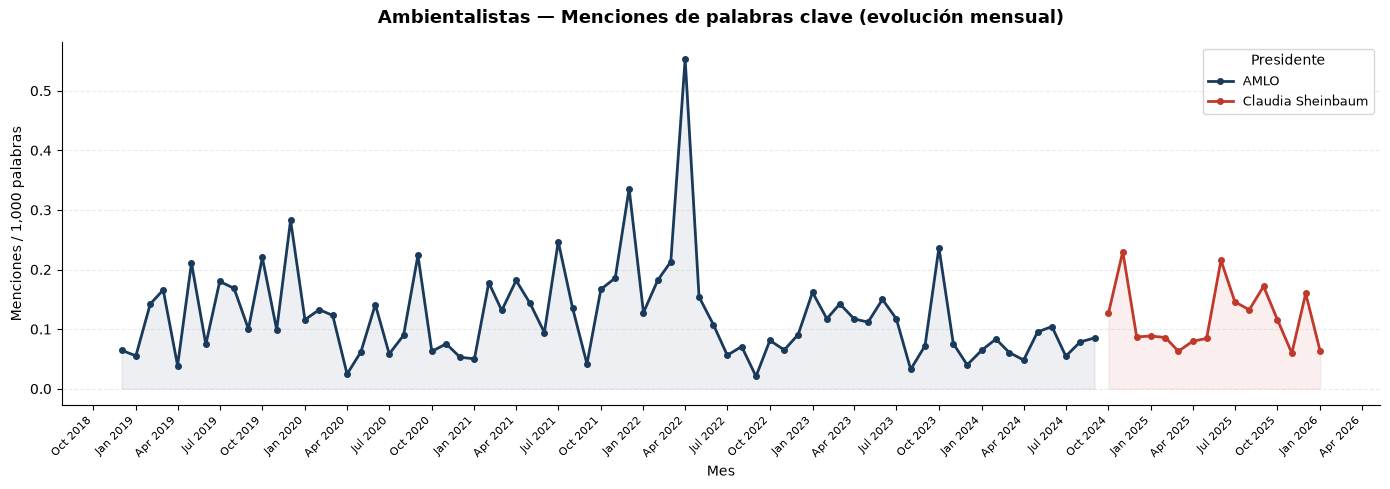


Gráfica guardada: ambientalistas_palabras_clave_timeline.png


In [5]:
# ============================================================
#  PALABRAS CLAVE — SUMA, EVOLUCIÓN MENSUAL (tasa por 1,000 palabras)
# ============================================================

if not _corpus:
    print("No hay archivos cargados. Revisa RUTA_DATOS y vuelve a ejecutar la celda de carga.")
else:
    filas_k = []
    for doc in _corpus:
        menciones = _contar(doc['texto'], PALABRAS_CLAVE)
        filas_k.append({
            'fecha':      doc['fecha'],
            'mes':        doc['mes'],
            'presidente': doc['presidente'],
            'menciones':  menciones,
            'por_1000':   round(menciones / doc['n_palabras'] * 1000, 4)
                          if doc['n_palabras'] > 0 else 0
        })
    df_palabras = pd.DataFrame(filas_k)

    # ── Tabla resumen ──────────────────────────────────────────
    print("═"*60)
    print(f"  {NOMBRE_GRUPO.upper()} — PALABRAS CLAVE (total y tasa por presidente)")
    print("═"*60)
    resumen_k = df_palabras.groupby('presidente').agg(
        menciones_totales=('menciones', 'sum'),
        tasa_promedio=('por_1000', 'mean')
    ).round(3)
    print(resumen_k.to_string())
    print("═"*60)

    # ── Gráfica: una sola línea (suma de palabras), agregada mensual ─
    df_mes_k = df_palabras.groupby(['mes', 'presidente'])['por_1000'].sum().reset_index()
    df_mes_k['mes_dt'] = pd.to_datetime(df_mes_k['mes'])

    _COLORES_P = {"AMLO": "#1A3A5C", "Claudia Sheinbaum": "#C0392B"}

    fig, ax = plt.subplots(figsize=(14, 5))
    for pres, color in _COLORES_P.items():
        dp = df_mes_k[df_mes_k['presidente'] == pres].sort_values('mes_dt')
        if not dp.empty:
            ax.plot(dp['mes_dt'], dp['por_1000'], color=color, linewidth=2,
                    marker='o', markersize=4, label=pres)
            ax.fill_between(dp['mes_dt'], dp['por_1000'], alpha=0.08, color=color)

    ax.set_title(TITULO_GRAFICA_PALABRAS_CLAVE, fontsize=13, fontweight='bold', pad=14)
    ax.set_xlabel("Mes", fontsize=10)
    ax.set_ylabel("Menciones / 1,000 palabras", fontsize=10)
    ax.legend(title="Presidente", fontsize=9)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.spines[['top','right']].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
    plt.tight_layout()

    _nombre_archivo = NOMBRE_GRUPO.lower().replace(' ', '_')
    plt.savefig(f"{_nombre_archivo}_palabras_clave_timeline.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nGráfica guardada: {_nombre_archivo}_palabras_clave_timeline.png")
